# The axes study: collocation density and horizon for the one fix that works

Companion to `analysis_converged.ipynb`. The eight-arm study (240 converged runs) found that only
pseudo-time stepping (Wang, Koohy, Lu & Perdikaris 2026) reproduces the van der Pol oscillation past
two periods; every regulariser variant converges onto a spliced off-loop trajectory and the plain and
resampled arms park at the origin. This notebook asks how that result moves with the two resources a
user would reach for: **more collocation points** (axis A: 20, 80, 320 points per unit time at
T = 14, 27, 40) and **a longer window** (axis C: T = 67 and 100, ten and fifteen periods, at density 20).

Three arms, seeds 0–9, the same convergence-assured protocol as the converged set (Adam to at least
60k epochs, plateau tolerance 1e-4 over 10k, polish cap 60): `pseudo_unw` (the subject), `base_unw`
(the plain baseline), `reg_resample_unw` (the published regulariser protocol of Babic, Rohrhofer &
Geiger 2025, the control). The density-20 column at T = 14, 27, 40 is the converged set itself, not a
rerun. Every number here is produced by `analysis_axes.py` (which imports the loader, metrics and
failure classifier of `analysis_converged.py`) and read back from `results/axes_runs.csv` and
`results/axes_summary.csv`; this notebook recomputes nothing.

Success means relative L2 against the reference below 0.15 over the whole window, the threshold of the
Graz papers. *Periods survived* is the time, in periods of the reference oscillation (6.663 time
units), at which the cumulative relative L2 first exceeds 0.15; a success survived the whole window.

In [1]:
import pandas as pd, numpy as np
from IPython.display import Image, display
from pathlib import Path
RES, FIG = Path('results'), Path('figures')
runs = pd.read_csv(RES / 'axes_runs.csv'); summ = pd.read_csv(RES / 'axes_summary.csv')
PERIOD = 6.663286859
pd.set_option('display.width', 220); pd.set_option('display.max_rows', 200)
print(f"{(runs.source == 'axes').sum()} axes runs + {(runs.source == 'converged').sum()} converged-set runs, "
      f"{len(summ)} cells; strict-rule convergence in {int(runs.converged.sum())}/{len(runs)} runs")

240 axes runs + 90 converged-set runs, 33 cells; strict-rule convergence in 319/330 runs


## 1. The headline table

One row per arm × density × horizon: success count out of `n`, median and best relative L2, the failure
classes of the non-successes, the median periods survived, and the median cost per run.

In [2]:
cols = ['arm', 'density', 'horizon', 'periods', 'n_points', 'n', 'converged', 'success', 'rel_l2_median',
        'rel_l2_min', 'parked', 'flow-following', 'diffuse', 'periods_survived_median', 'hours_median']
summ.sort_values(['arm', 'density', 'horizon'])[cols].style.format({'periods': '{:.1f}', 'rel_l2_median': '{:.2e}',
    'rel_l2_min': '{:.2e}', 'periods_survived_median': '{:.2f}', 'hours_median': '{:.2f}'}).hide(axis='index')

arm,density,horizon,periods,n_points,n,converged,success,rel_l2_median,rel_l2_min,parked,flow-following,diffuse,periods_survived_median,hours_median
base_unw,20.000000,14.000000,2.1,280,10,10,5,3.57e-01,5.16e-05,5,0,0,1.58,0.05
base_unw,20.000000,27.000000,4.1,540,10,10,0,9.50e-01,8.42e-01,9,0,1,0.35,0.11
base_unw,20.000000,40.000000,6.0,800,10,10,0,9.35e-01,8.52e-01,10,0,0,0.37,0.17
base_unw,20.000000,67.000000,10.1,1340,10,10,0,9.62e-01,9.59e-01,10,0,0,0.36,0.34
base_unw,20.000000,100.000000,15.0,2000,10,10,0,9.78e-01,9.74e-01,10,0,0,0.36,0.59
base_unw,80.000000,14.000000,2.1,1120,10,10,10,6.74e-05,4.10e-05,0,0,0,2.10,0.30
base_unw,80.000000,27.000000,4.1,2160,10,10,0,9.01e-01,9.01e-01,10,0,0,0.36,0.69
base_unw,80.000000,40.000000,6.0,3200,10,10,0,9.34e-01,9.34e-01,10,0,0,0.36,1.58
base_unw,320.000000,14.000000,2.1,4480,10,10,10,1.30e-04,4.15e-05,0,0,0,2.10,2.13
base_unw,320.000000,27.000000,4.1,8640,10,10,0,9.01e-01,9.01e-01,10,0,0,0.36,1.71


## 2. Axis A: collocation density

Does density help the fix, or only raise the cost? The earlier density study (`../Collocation_study`,
5 to 320 points per unit time) ran before any fix and at a fixed budget, and saw only parking.

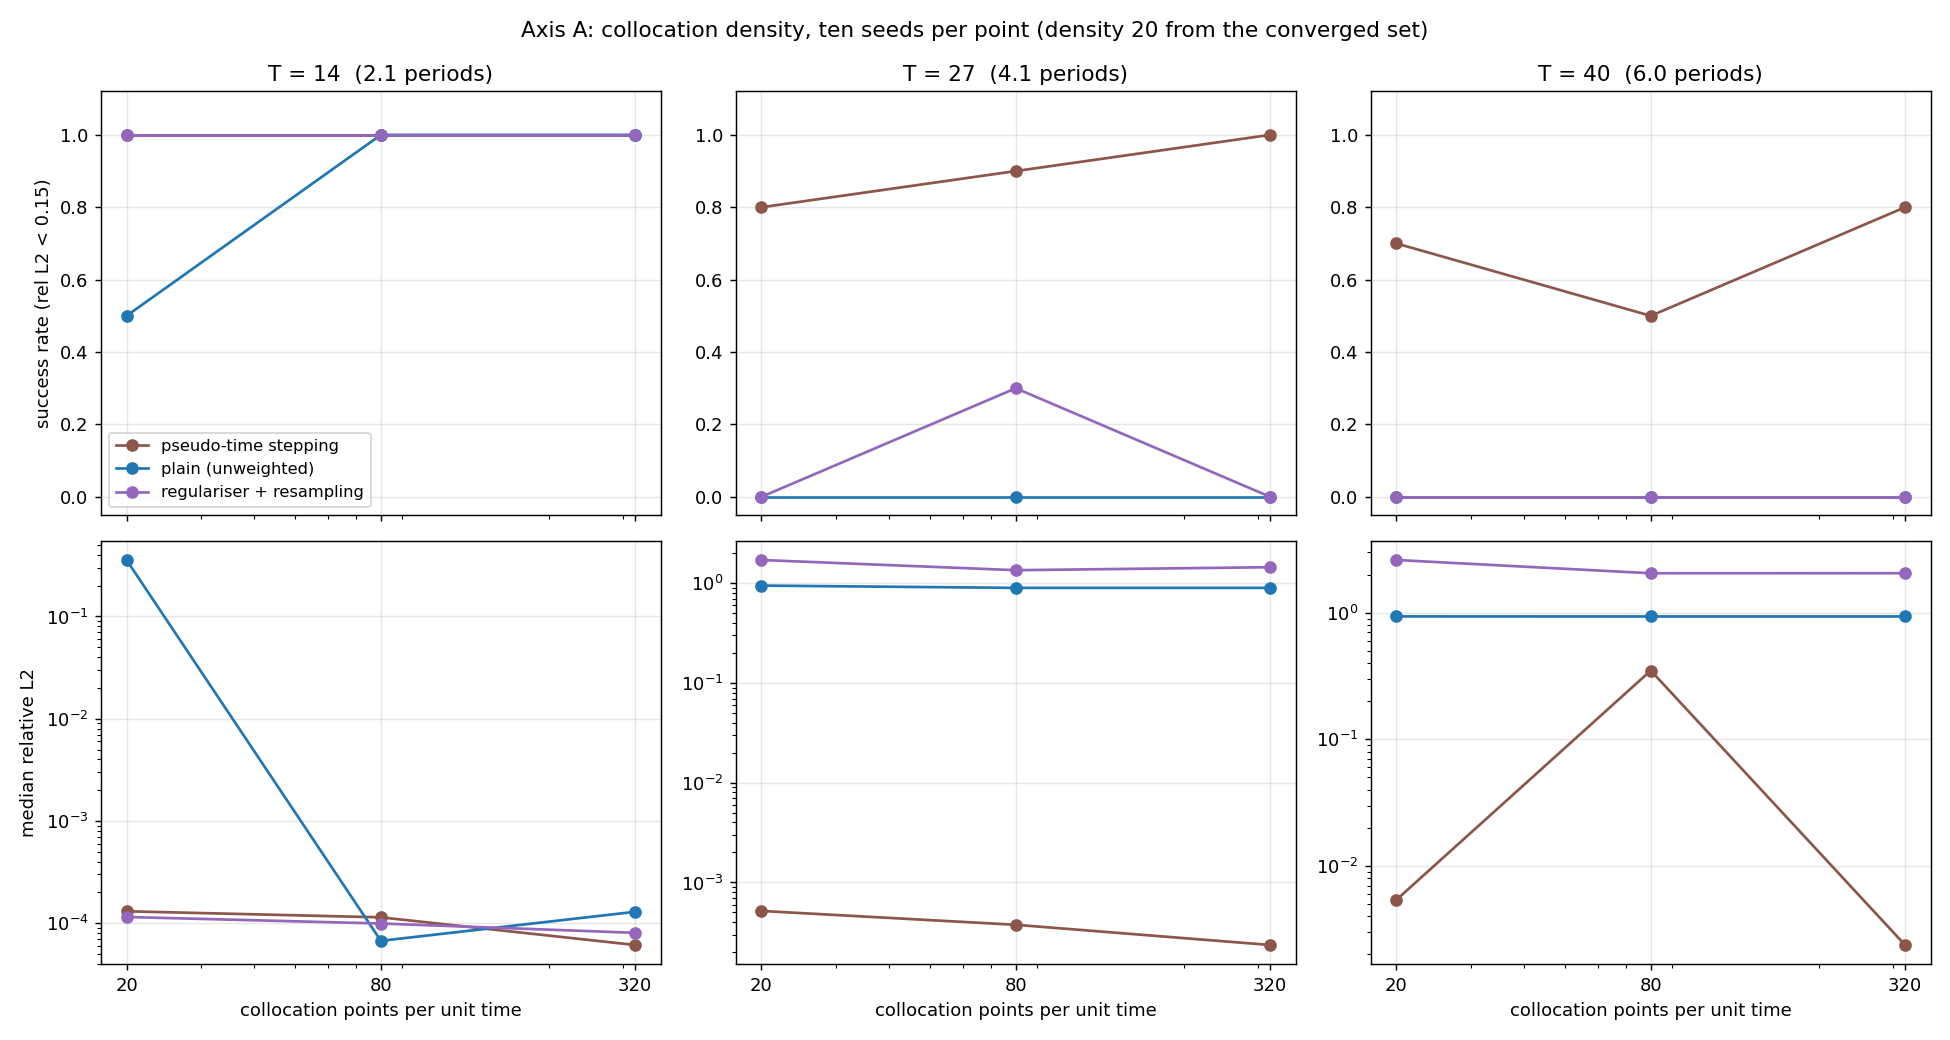

successes / n per (arm, T) across densities


density                   20.0       80.0       320.0
arm              horizon                             
base_unw         14.0      5/10      10/10      10/10
                 27.0      0/10       0/10       0/10
                 40.0      0/10       0/10       0/10
                 67.0      0/10  <NA>/<NA>  <NA>/<NA>
                 100.0     0/10  <NA>/<NA>  <NA>/<NA>
pseudo_unw       14.0     10/10      10/10      10/10
                 27.0      8/10       9/10      10/10
                 40.0      7/10       5/10       8/10
                 67.0      1/10  <NA>/<NA>  <NA>/<NA>
                 100.0     0/10  <NA>/<NA>  <NA>/<NA>
reg_resample_unw 14.0     10/10      10/10      10/10
                 27.0      0/10       3/10       0/10
                 40.0      0/10       0/10       0/10
                 67.0      0/10  <NA>/<NA>  <NA>/<NA>
                 100.0     0/10  <NA>/<NA>  <NA>/<NA>

In [3]:
display(Image(FIG / 'a01_density.png'))
piv = summ.pivot_table(index=['arm', 'horizon'], columns='density', values='success', aggfunc='first')
n = summ.pivot_table(index=['arm', 'horizon'], columns='density', values='n', aggfunc='first')
print('successes / n per (arm, T) across densities'); display(piv.astype('Int64').astype(str) + '/' + n.astype('Int64').astype(str))

## 3. Axis C: horizon

Where is the fix's own wall, and what does its failure look like there?

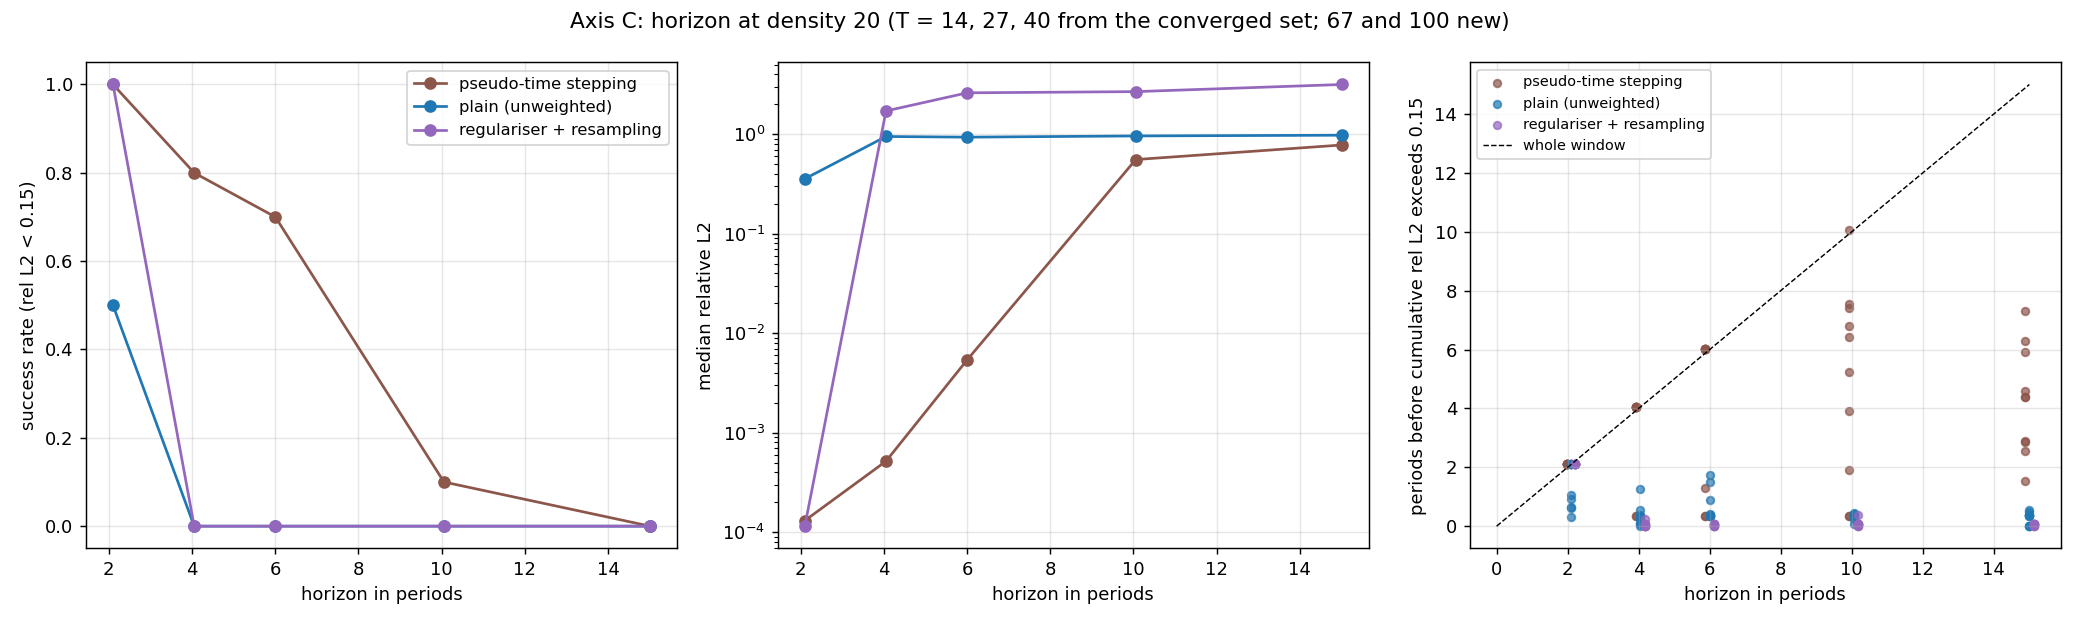

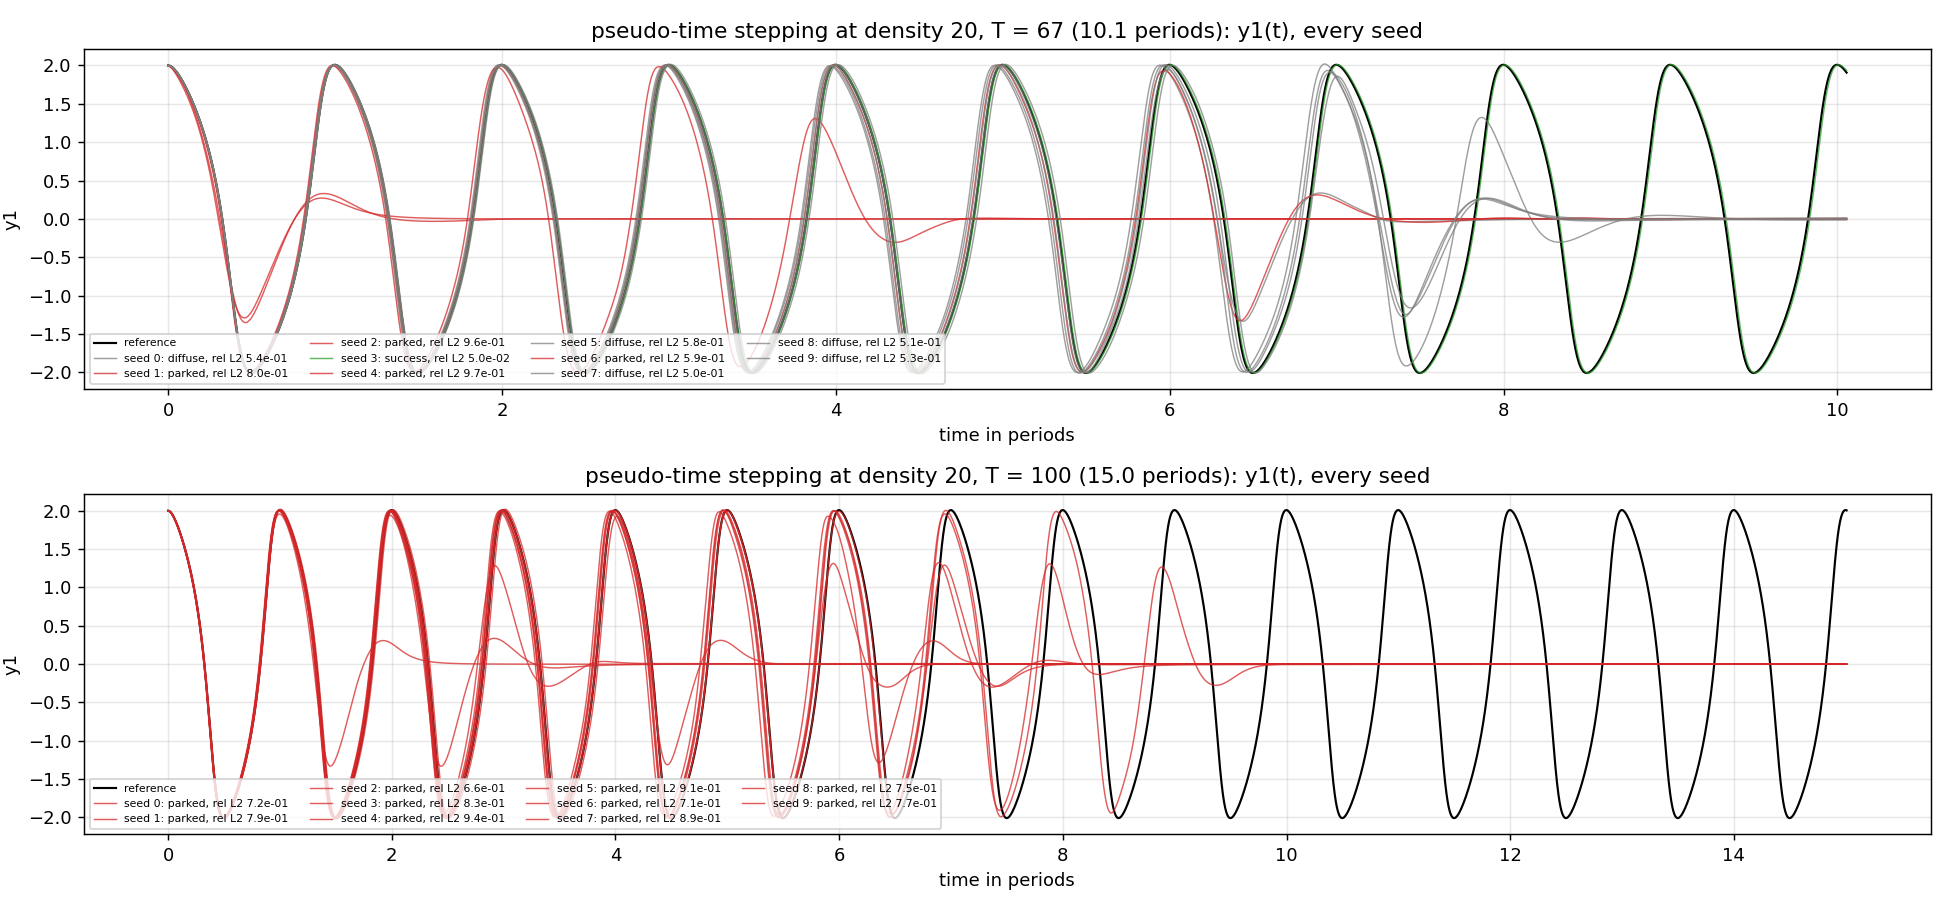

tag,rel_l2,failure_class,periods_survived,frac_near_origin,max_modulus,loss_total,tau_final,adam_epochs,lbfgs_restarts,converged
pseudo_unw_T67_s0,5.36e-01,diffuse,3.92,0.16,2.83,1.3e-02,0.68,61500,12,True
pseudo_unw_T67_s1,7.97e-01,parked,1.92,0.55,2.82,1.3e-02,0.86,60250,12,True
pseudo_unw_T67_s2,9.63e-01,parked,0.36,0.89,2.00,1.3e-02,0.83,60500,5,True
pseudo_unw_T67_s3,4.97e-02,success,10.06,0.00,2.83,2.0e-05,0.59,79500,60,False
pseudo_unw_T67_s4,9.65e-01,parked,0.34,0.90,2.00,1.3e-02,0.94,64000,4,True
pseudo_unw_T67_s5,5.78e-01,diffuse,6.80,0.30,2.84,1.3e-02,0.66,60000,8,True
pseudo_unw_T67_s6,5.89e-01,parked,6.42,0.30,2.83,1.3e-02,1.23,61500,7,True
pseudo_unw_T67_s7,4.99e-01,diffuse,7.55,0.20,2.84,1.3e-02,0.72,66250,7,True
pseudo_unw_T67_s8,5.06e-01,diffuse,7.40,0.20,2.84,1.3e-02,0.71,60000,8,True
pseudo_unw_T67_s9,5.29e-01,diffuse,5.24,0.20,2.83,1.3e-02,0.76,61250,7,True


In [4]:
display(Image(FIG / 'a02_horizon.png'))
display(Image(FIG / 'a06_pseudo_long_horizon.png'))
long = runs[(runs.arm == 'pseudo_unw') & (runs.horizon >= 67)].sort_values(['horizon', 'seed'])
long[['tag', 'rel_l2', 'failure_class', 'periods_survived', 'frac_near_origin', 'max_modulus', 'loss_total',
      'tau_final', 'adam_epochs', 'lbfgs_restarts', 'converged']].style.format({'rel_l2': '{:.2e}',
      'loss_total': '{:.1e}', 'periods_survived': '{:.2f}', 'frac_near_origin': '{:.2f}', 'max_modulus': '{:.2f}',
      'tau_final': '{:.2f}'}).hide(axis='index')

## 4. A registered prediction: the parked loss falls like 1/T

Section 3 of `theory.md` prices the splice onto the origin under resampling at order |y|² / (hT): the
transition layer of width h is sampled, and its squared residual is averaged over a window of length T.
If the parked runs of the resampled arms sit at that stationary point, their converged loss times T
should be a constant. The fixed-set plain arm has no such law: its layer hides between points.

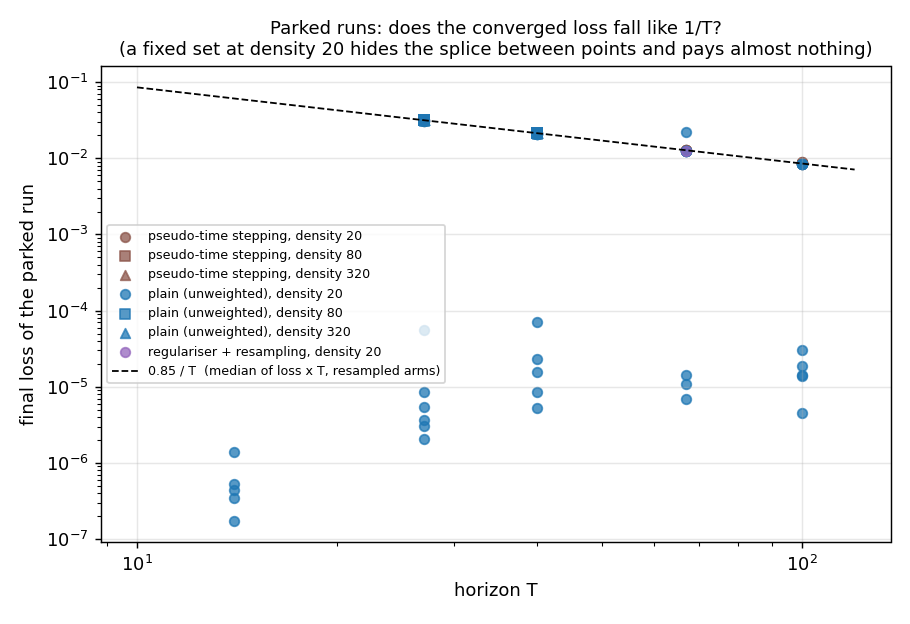

count  median    min    max
arm              density horizon                             
base_unw         20.0    14.0         5   0.000  0.000  0.000
                         27.0         9   0.000  0.000  0.848
                         40.0        10   0.421  0.000  0.846
                         67.0        10   0.842  0.000  1.470
                         100.0       10   0.423  0.000  0.847
                 80.0    27.0        10   0.846  0.846  0.847
                         40.0        10   0.847  0.846  0.847
                 320.0   27.0        10   0.846  0.846  0.846
                         40.0        10   0.847  0.846  0.847
pseudo_unw       20.0    27.0         2   0.847  0.844  0.849
                         40.0         2   0.851  0.848  0.853
                         67.0         4   0.861  0.851  0.873
                         100.0       10   0.861  0.849  0.899
                 80.0    27.0         1   0.859  0.859  0.859
                         40.0         4   0.847  0.847  0.847
                 320.0   40.0         1   0.848  0.848  0.848
reg_resample_unw 20.0    67.0         1   0.844  0.844  0.844

In [5]:
display(Image(FIG / 'a04_parked_loss_vs_T.png'))
p = runs[(runs.failure_class == 'parked')].copy(); p['loss_x_T'] = p.loss_total * p.horizon
p.groupby(['arm', 'density', 'horizon']).loss_x_T.agg(['count', 'median', 'min', 'max']).round(3)

## 5. Failure classes and cost

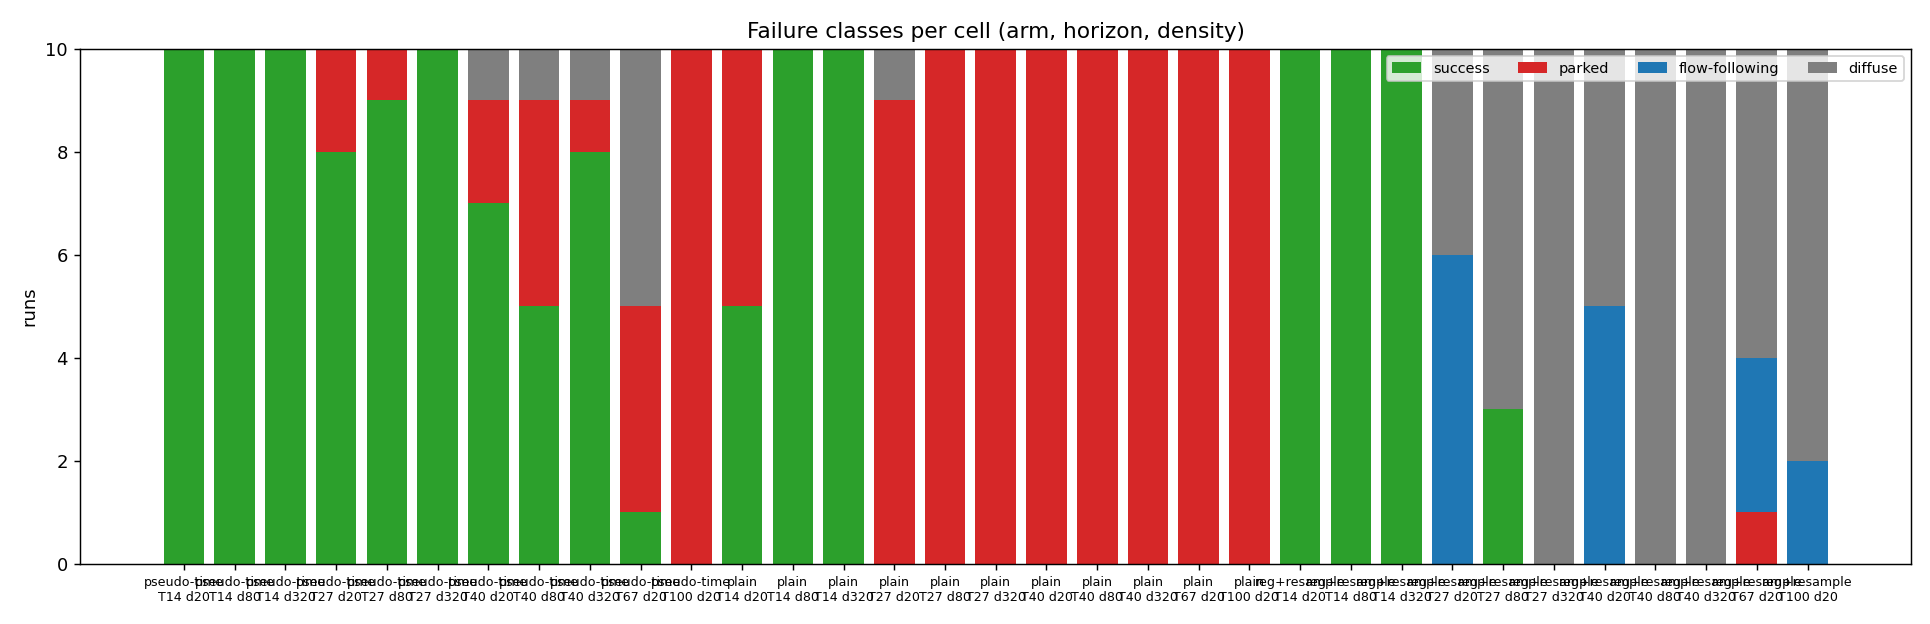

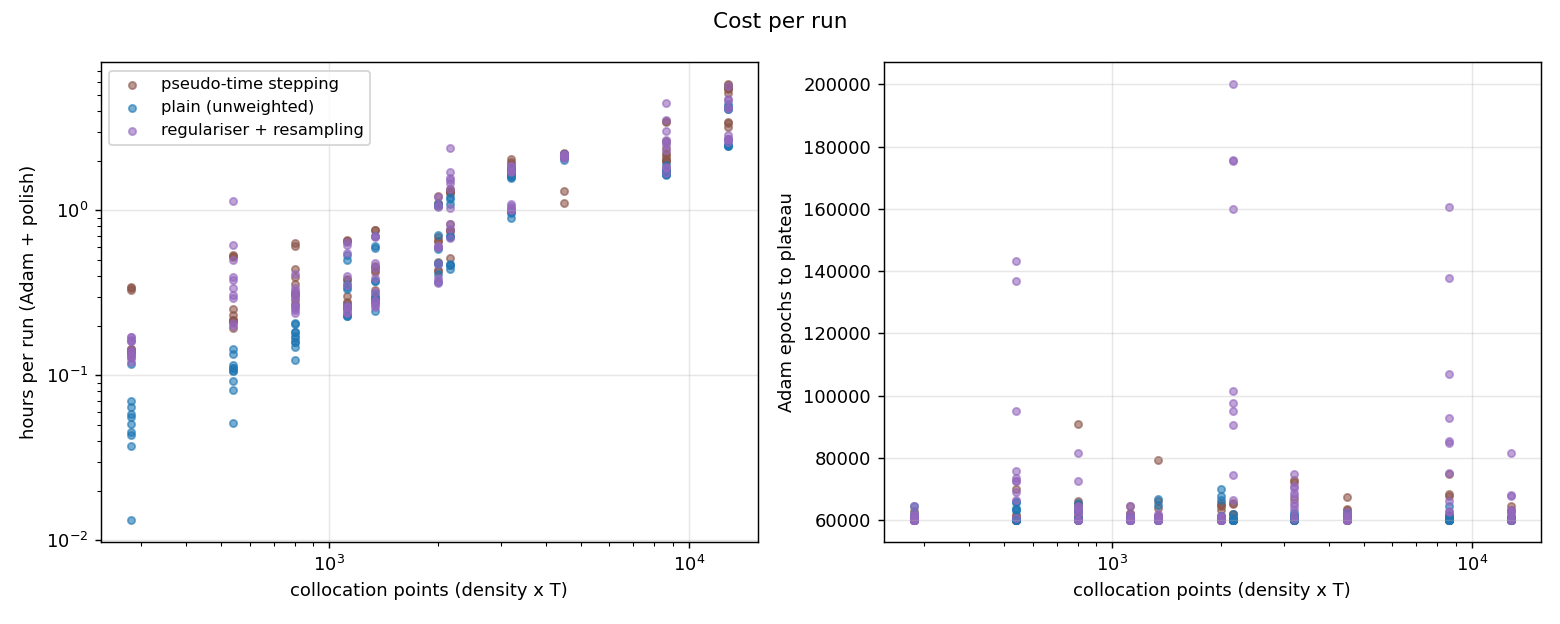

density                   20.0   80.0   320.0
arm              horizon                     
base_unw         14.0      0.05   0.30   2.13
                 27.0      0.11   0.69   1.71
                 40.0      0.17   1.58   3.40
                 67.0      0.34    NaN    NaN
                 100.0     0.59    NaN    NaN
pseudo_unw       14.0      0.14   0.34   2.16
                 27.0      0.22   1.04   2.19
                 40.0      0.34   1.77   5.48
                 67.0      0.43    NaN    NaN
                 100.0     0.67    NaN    NaN
reg_resample_unw 14.0      0.15   0.31   2.14
                 27.0      0.36   1.41   2.57
                 40.0      0.28   1.39   3.51
                 67.0      0.35    NaN    NaN
                 100.0     0.60    NaN    NaN

In [6]:
display(Image(FIG / 'a05_failure_classes.png')); display(Image(FIG / 'a03_cost.png'))
summ.pivot_table(index=['arm', 'horizon'], columns='density', values='hours_median', aggfunc='first').round(2)

## 6. Reading (final: all 240 axes runs in; the cell below prints the counts from the CSV)

**A note on the classifier.** `classify` in `analysis_converged.py` calls a run *parked* when more than 30 % of
the window sits within 0.2 of the origin. At T = 67 and 100 several pseudo-time failures ride the loop for
four to eight periods before parking, so the near-origin fraction stays under 0.3 and they read as
*diffuse*. They are late parks; the *periods survived* column is the right readout for them and is used
throughout this notebook. Nothing in these two arms wanders off the loop (max modulus stays at 2.83).

In [7]:
def cell(arm, d, T):
    s = summ[(summ.arm == arm) & (summ.density == d) & (summ.horizon == T)]
    return f"{int(s.success.iloc[0])}/{int(s.n.iloc[0])}" if len(s) else "not yet"
print("pseudo-time  T=27: density 20", cell('pseudo_unw', 20, 27), "| 80", cell('pseudo_unw', 80, 27), "| 320", cell('pseudo_unw', 320, 27))
print("pseudo-time  T=40: density 20", cell('pseudo_unw', 20, 40), "| 80", cell('pseudo_unw', 80, 40), "| 320", cell('pseudo_unw', 320, 40))
print("plain        T=14: density 20", cell('base_unw', 20, 14), "| 80", cell('base_unw', 80, 14), "| 320", cell('base_unw', 320, 14))
print("plain        T=27: density 20", cell('base_unw', 20, 27), "| 80", cell('base_unw', 80, 27), "| 320", cell('base_unw', 320, 27))
print("reg+resample T=27: density 20", cell('reg_resample_unw', 20, 27), "| 80", cell('reg_resample_unw', 80, 27), "| 320", cell('reg_resample_unw', 320, 27))
print("pseudo-time at density 20: T=67", cell('pseudo_unw', 20, 67), "| T=100", cell('pseudo_unw', 20, 100))
p = runs[(runs.failure_class == 'parked')].copy(); p['loss_x_T'] = p.loss_total * p.horizon
resampled = p[p.arm.isin(['pseudo_unw', 'reg_resample_unw']) | (p.density > 20)]
print(f"loss x T over the {len(resampled)} parked runs with a sampled transition layer: "
      f"median {resampled.loss_x_T.median():.2f}, range {resampled.loss_x_T.min():.2f} to {resampled.loss_x_T.max():.2f}")

pseudo-time  T=27: density 20 8/10 | 80 9/10 | 320 10/10
pseudo-time  T=40: density 20 7/10 | 80 5/10 | 320 8/10
plain        T=14: density 20 5/10 | 80 10/10 | 320 10/10
plain        T=27: density 20 0/10 | 80 0/10 | 320 0/10
reg+resample T=27: density 20 0/10 | 80 3/10 | 320 0/10
pseudo-time at density 20: T=67 1/10 | T=100 0/10
loss x T over the 65 parked runs with a sampled transition layer: median 0.85, range 0.84 to 0.90


**What the numbers say.**

1. *Horizon (axis C).* Pseudo-time stepping's own wall at density 20 lies between six and ten periods:
   7/10 at T = 40, 1/10 at T = 67 (and that success is marginal, 5e-2), 0/10 at T = 100. The failure mode
   is the parked branch arriving late, after four to eight good periods. The plain and regulariser arms
   fail from four periods on, exactly as in the converged set.
2. *Density (axis A).* At two periods, density 80 lifts the plain baseline from 5/10 to 10/10, so the
   fixed-budget density study's "no effect" verdict did not survive training to convergence. For
   pseudo-time stepping density helps at four periods (8/10, 9/10, 10/10 at densities 20, 80, 320)
   and not at six (7/10, 5/10, 8/10), with different seeds parking at each density and every
   parked run at the same loss whatever the density (the 1/T law of item 3: the parked branch is already
   fully sampled, so denser points do not raise its price). Ten seeds cannot separate the six-period rates.
   The published regulariser protocol has 3/10 at T = 27 and density 80 (two of the three budget-limited,
   Adam at or near its cap) and 0/10 at density 320; 0/10 at T = 40 and density 320.
3. *The 1/T law.* Every parked run whose transition layer is actually sampled (the resampled arms at any
   density, and the plain arm once the fixed set is dense enough that the layer cannot hide between
   points) converges to a loss with loss × T constant near 0.85, from T = 27 to T = 100, at every
   density. The plain arm's parked runs at density 20 sit three to four orders of magnitude lower because
   their fixed set leaves room to hide the layer. This is the prediction of `theory.md` sections 3 and 4.
4. *Cost.* Hours per run grow roughly linearly with the number of collocation points (density × T);
   the density-320 runs at T = 40 are the most expensive in the whole programme.


In [8]:
runs[['tag', 'arm', 'density', 'horizon', 'seed', 'rel_l2', 'failure_class', 'periods_survived', 'loss_total',
      'tau_final', 'adam_epochs', 'lbfgs_restarts', 'converged', 'hours', 'source']].sort_values(
      ['arm', 'density', 'horizon', 'seed']).style.format({'rel_l2': '{:.2e}', 'loss_total': '{:.1e}',
      'periods_survived': '{:.2f}', 'tau_final': '{:.2f}', 'hours': '{:.2f}'}).hide(axis='index')

tag,arm,density,horizon,seed,rel_l2,failure_class,periods_survived,loss_total,tau_final,adam_epochs,lbfgs_restarts,converged,hours,source
base_unw_T14_s0,base_unw,20.000000,14.000000,0,8.02e-05,success,2.10,2.2e-07,nan,62000,8,True,0.04,converged
base_unw_T14_s1,base_unw,20.000000,14.000000,1,7.13e-01,parked,1.06,5.3e-07,nan,60000,13,True,0.12,converged
base_unw_T14_s2,base_unw,20.000000,14.000000,2,5.16e-05,success,2.10,3.7e-07,nan,60000,7,True,0.06,converged
base_unw_T14_s3,base_unw,20.000000,14.000000,3,8.51e-01,parked,0.60,3.5e-07,nan,64750,4,True,0.06,converged
base_unw_T14_s4,base_unw,20.000000,14.000000,4,1.73e-04,success,2.10,5.2e-07,nan,60000,9,True,0.01,converged
base_unw_T14_s5,base_unw,20.000000,14.000000,5,1.88e-04,success,2.10,5.6e-07,nan,60250,8,True,0.04,converged
base_unw_T14_s6,base_unw,20.000000,14.000000,6,8.40e-01,parked,0.65,1.8e-07,nan,60000,4,True,0.05,converged
base_unw_T14_s7,base_unw,20.000000,14.000000,7,1.79e-04,success,2.10,2.5e-07,nan,61250,7,True,0.05,converged
base_unw_T14_s8,base_unw,20.000000,14.000000,8,9.45e-01,parked,0.30,1.4e-06,nan,60250,19,True,0.07,converged
base_unw_T14_s9,base_unw,20.000000,14.000000,9,7.65e-01,parked,0.91,4.5e-07,nan,60000,6,True,0.06,converged
